# **DATA ANALYSIS PYTHON PROJECT - BLINKIT ANALYSIS**

## **Import Libraries**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

## **Import Raw Data**

In [7]:
df = pd.read_csv("/Users/ayushchaudhary/Documents/Sales-Data-Analysis-Project/data/BlinkIT Grocery Data.csv")

## **Sample Data**

In [8]:
df.head(10)

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
0,Regular,FDX32,Fruits and Vegetables,2012,OUT049,Tier 1,Medium,Supermarket Type1,0.100014,15.10,145.4786,5.0
1,Low Fat,NCB42,Health and Hygiene,2022,OUT018,Tier 3,Medium,Supermarket Type2,0.008596,11.80,115.3492,5.0
2,Regular,FDR28,Frozen Foods,2016,OUT046,Tier 1,Small,Supermarket Type1,0.025896,13.85,165.0210,5.0
3,Regular,FDL50,Canned,2014,OUT013,Tier 3,High,Supermarket Type1,0.042278,12.15,126.5046,5.0
4,Low Fat,DRI25,Soft Drinks,2015,OUT045,Tier 2,Small,Supermarket Type1,0.033970,19.60,55.1614,5.0
5,low fat,FDS52,Frozen Foods,2020,OUT017,Tier 2,Small,Supermarket Type1,0.005505,8.89,102.4016,5.0
6,Low Fat,NCU05,Health and Hygiene,2011,OUT010,Tier 3,Small,Grocery Store,0.098312,11.80,81.4618,5.0
7,Low Fat,NCD30,Household,2015,OUT045,Tier 2,Small,Supermarket Type1,0.026904,19.70,96.0726,5.0
8,Low Fat,FDW20,Fruits and Vegetables,2014,OUT013,Tier 3,High,Supermarket Type1,0.024129,20.75,124.1730,5.0
9,Low Fat,FDX25,Canned,2018,OUT027,Tier 3,Medium,Supermarket Type3,0.101562,NaN,181.9292,5.0


In [9]:
df.tail(10)

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
8513,Regular,DRY23,Soft Drinks,2018,OUT027,Tier 3,Medium,Supermarket Type3,0.108568,NaN,42.9112,4.0
8514,low fat,FDA11,Baking Goods,2018,OUT027,Tier 3,Medium,Supermarket Type3,0.043029,NaN,94.7436,4.0
8515,low fat,FDK38,Canned,2018,OUT027,Tier 3,Medium,Supermarket Type3,0.053032,NaN,149.1734,4.0
8516,low fat,FDO38,Canned,2018,OUT027,Tier 3,Medium,Supermarket Type3,0.072486,NaN,78.9986,4.0
8517,low fat,FDG32,Fruits and Vegetables,2018,OUT027,Tier 3,Medium,Supermarket Type3,0.175143,NaN,222.3772,4.0
8518,low fat,NCT53,Health and Hygiene,2018,OUT027,Tier 3,Medium,Supermarket Type3,0.000000,NaN,164.5526,4.0
8519,low fat,FDN09,Snack Foods,2018,OUT027,Tier 3,Medium,Supermarket Type3,0.034706,NaN,241.6828,4.0
8520,low fat,DRE13,Soft Drinks,2018,OUT027,Tier 3,Medium,Supermarket Type3,0.027571,NaN,86.6198,4.0
8521,reg,FDT50,Dairy,2018,OUT027,Tier 3,Medium,Supermarket Type3,0.107715,NaN,97.8752,4.0
8522,reg,FDM58,Snack Foods,2018,OUT027,Tier 3,Medium,Supermarket Type3,0.000000,NaN,112.2544,4.0


## **Size of data**

In [11]:
print("Size of data :", df.shape)

Size of data : (8523, 12)


## **Field info**

In [12]:
df.columns

Index(['Item Fat Content', 'Item Identifier', 'Item Type',
       'Outlet Establishment Year', 'Outlet Identifier',
       'Outlet Location Type', 'Outlet Size', 'Outlet Type', 'Item Visibility',
       'Item Weight', 'Sales', 'Rating'],
      dtype='str')

In [13]:
df.dtypes

Item Fat Content                 str
Item Identifier                  str
Item Type                        str
Outlet Establishment Year      int64
Outlet Identifier                str
Outlet Location Type             str
Outlet Size                      str
Outlet Type                      str
Item Visibility              float64
Item Weight                  float64
Sales                        float64
Rating                       float64
dtype: object

##  **DATA CLEANING** 

In [35]:
print(df['Item Fat Content'].unique())

<StringArray>
['Regular', 'Low Fat']
Length: 2, dtype: str


In [36]:
df['Item Fat Content']=df['Item Fat Content'].replace({'LF': 'Low Fat','low fat':'Low Fat','reg':'Regular','Low key':'Low Fat'})

In [37]:
print(df['Item Fat Content'].unique())

<StringArray>
['Regular', 'Low Fat']
Length: 2, dtype: str


In [39]:
df['Item Weight'] = df['Item Weight'].fillna(0)

## **CHARTS REQUIREMENTS**


#### **Total sales by fat content**

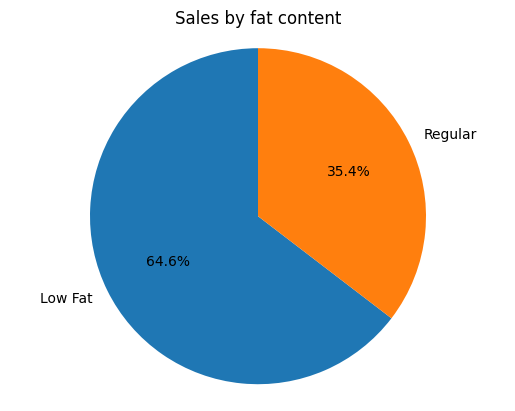

In [57]:
sales_by_fat_content = df.groupby('Item Fat Content')['Sales'].sum()
plt.pie(sales_by_fat_content,labels=sales_by_fat_content.index,autopct='%.1f%%',startangle=90)
plt.title('Sales by fat content')
plt.axis('equal')
plt.show()


#### **Total sales by Item type**

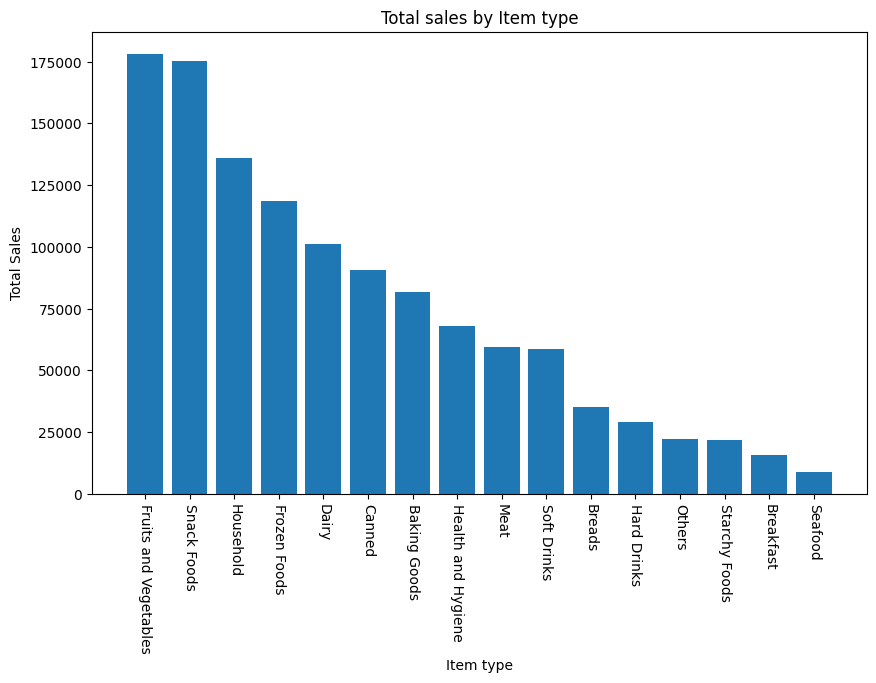

In [61]:
sales_by_item_type = df.groupby('Item Type')['Sales'].sum().sort_values(ascending=False)
plt.figure(figsize=(10,6))
bars = plt.bar(sales_by_item_type.index,sales_by_item_type.values)
plt.xticks(rotation=-90)
plt.xlabel('Item type')
plt.ylabel('Total Sales')
plt.title('Total sales by Item type')
plt.show()

#### **Fat content by outlet for Total Sales**

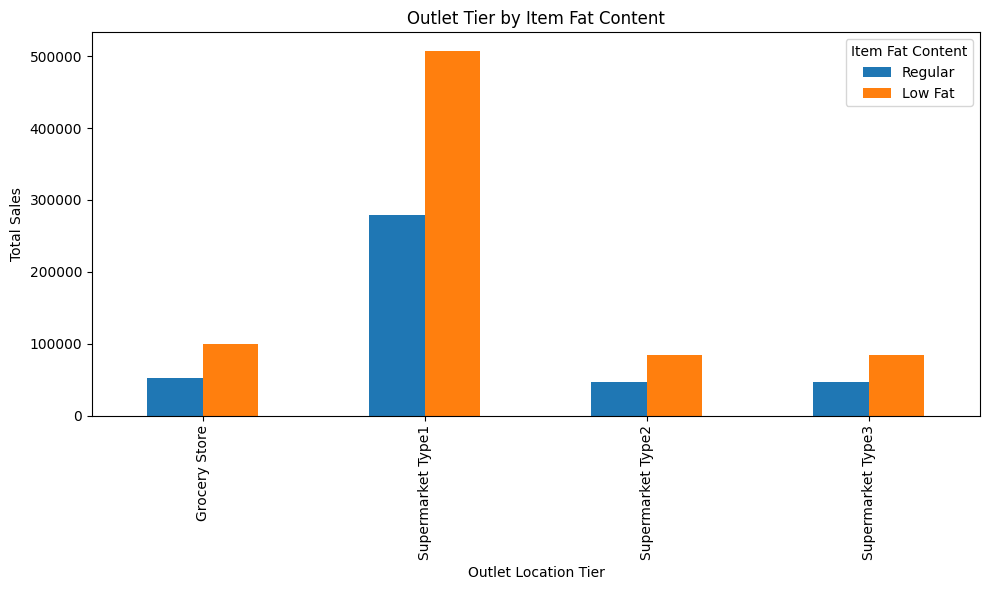

In [73]:
grouped = df.groupby(['Outlet Type','Item Fat Content'])['Sales'].sum().unstack()
grouped = grouped[['Regular','Low Fat']]
ax = grouped.plot(kind='bar',figsize = (10,6),title ='Outlet Tier by Item Fat Content')
plt.xlabel('Outlet Location Tier')
plt.ylabel('Total Sales')
plt.legend(title ='Item Fat Content')
plt.tight_layout()
plt.show()

#### **Total Sales by outlet establishment**

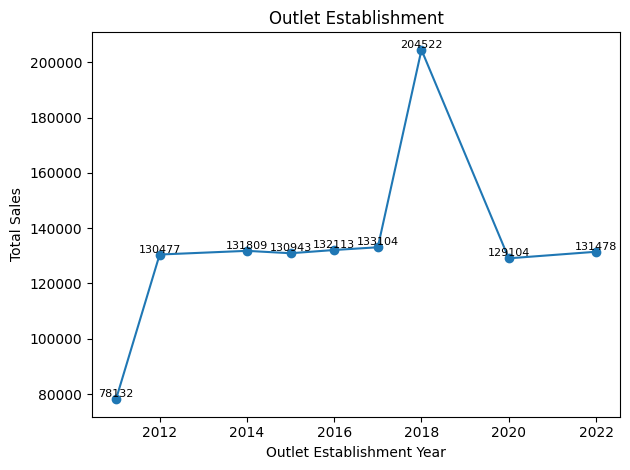

In [76]:
sales_by_year = df.groupby('Outlet Establishment Year')['Sales'].sum().sort_index()
plt.Figure(figsize=(10,6))
plt.plot(sales_by_year.index,sales_by_year.values,marker='o' ,linestyle='-')
plt.xlabel('Outlet Establishment Year')
plt.ylabel('Total Sales')
plt.title('Outlet Establishment')
for x,y in zip(sales_by_year.index,sales_by_year.values):
    plt.text(x,y,f'{y:.0f}',ha='center', va='bottom',fontsize=8)
plt.tight_layout()
plt.show()


#### **Sales by outlet size**

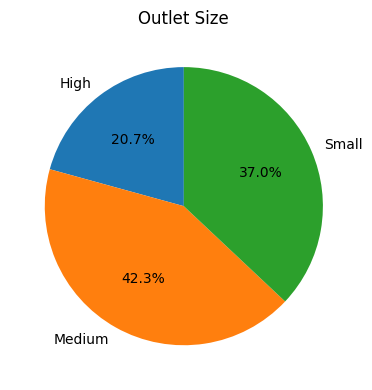

In [78]:
sales_by_size=df.groupby('Outlet Size')['Sales'].sum()
plt.figure(figsize=(4, 4))
plt.pie(sales_by_size,labels=sales_by_size.index,autopct='%1.1f%%',startangle=90)
plt.title('Outlet Size')
plt.tight_layout()
plt.show()

#### **Sales by outlet Location**

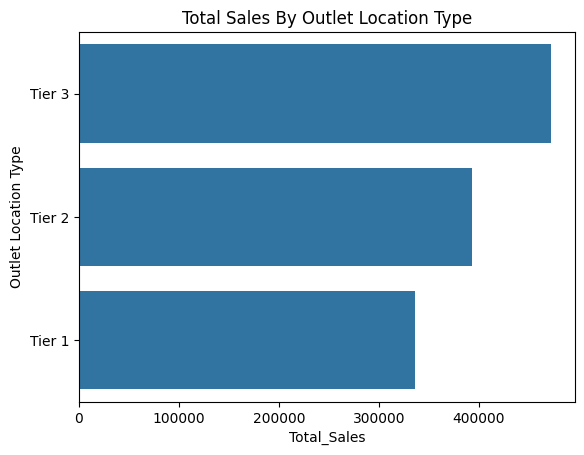

In [ ]:
sales_by_location = df.groupby('Outlet Location Type')['Sales'].sum().reset_index()
sales_by_location = sales_by_location.sort_values('Sales',ascending=False)
plt.Figure(figsize=(15,2))
ax = sns.barplot(x='Sales',y='Outlet Location Type',data=sales_by_location)
plt.title('Total Sales By Outlet Location Type')
plt.xlabel('Total_Sales')
plt.ylabel('Outlet Location Type')
plt.tight_layout()
plt.show()